In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.io import netcdf_file
from netCDF4 import Dataset
from matplotlib.colors import LogNorm

# Set global font size
plt.rcParams['font.size'] = 14 

In [6]:
resolution = 48
tmax = 1e-3

data_hires = np.loadtxt(f'../../run_firm3d/precise_QH_double/trajectory_data_vmec_tol_1e-10_resolution_96_tmax_{tmax}_trapped.txt')
s_hires = data_hires[0:10000, 1]
t_hires = data_hires[0:10000, 0]
theta_hires = data_hires[0:10000, 2]
phi_hires = data_hires[0:10000, 3]
vpar_hires = data_hires[0:10000, 4]

In [7]:
iorbit = 0

data_simple_5 = Dataset('../../run_simple/precise_QH_single/npoints_4096/orbits.nc', 'r')
# data_simple = netcdf_file('trace_orbit_simple_20250725_122010.nc', 'r')
s_simple_5 = data_simple_5.variables['s'][()][:,iorbit]
t_simple_5 = data_simple_5.variables['time'][()][:,iorbit]
theta_simple_5 = data_simple_5.variables['theta'][()][:,iorbit]
phi_simple_5 = data_simple_5.variables['phi'][()][:,iorbit]
vpar_simple_5 = data_simple_5.variables['v_par'][()][:,iorbit]

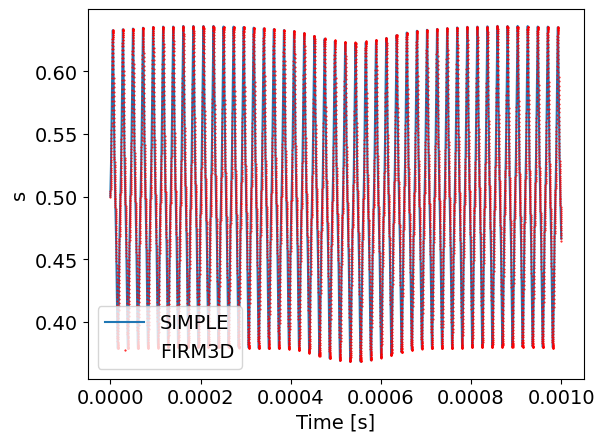

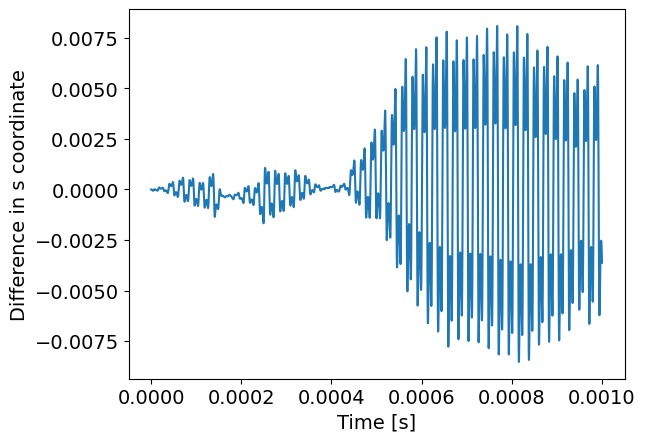

In [9]:
plt.figure()
plt.plot(t_simple_5, s_simple_5, label='SIMPLE')
plt.plot(t_hires, s_hires, linestyle='None', marker='.', markersize=1, label='FIRM3D', color='red')
plt.xlabel('Time [s]')
plt.ylabel('s')
plt.savefig('precise_QH_orbit_comparison.png')
plt.legend()

plt.figure()
plt.plot(t_hires, s_hires - s_simple_5[0:-1])
plt.xlabel('Time [s]')
plt.ylabel('Difference in s coordinate')
plt.savefig('precise_QH_orbit_comparison_s_diff.png')
